# Разметка WD-14 Tagger + EDA аналитика

**Цель работы:** Локальный запуск инференса разметчика WD-14 Tagger и проведение динамического анализа распределения классов.

In [1]:
# Шаг 1: Установка необходимых библиотек

In [2]:
import os
import csv
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import Counter
import onnxruntime as ort
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

e:\Projects\Auto-VideoGame-Assets-Pipeline\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Инициализация папок проекта

In [3]:
# Динамический поиск папки датасета
import os
if os.path.exists(os.path.join("data", "processed_1172")):
    DATASET_DIR = os.path.join("data", "processed_1172")
else:
    DATASET_DIR = os.path.join("..", "data", "processed_1172")

TRIGGER_TOKEN = "@sltn"

if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)
    print(f"⚠️ Папка {DATASET_DIR} не найдена. Создана пустая папка.")
else:
    images = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"✅ Найдено {len(images)} изображений в папке {DATASET_DIR}")

✅ Найдено 1172 изображений в папке data\processed_1172


## 3. Загрузка модели SmilingWolf WD-14 с Hugging Face
Мы скачиваем модель `wd-v1-4-convnext-tagger-v2` локально через официальный API Hugging Face.

In [4]:
print("📥 Загрузка модели SmilingWolf WD-14 Tagger...")

# Скачиваем файл весов ONNX и маппинг тегов CSV
model_path = hf_hub_download(repo_id="SmilingWolf/wd-v1-4-moat-tagger-v2", filename="model.onnx")
tags_csv_path = hf_hub_download(repo_id="SmilingWolf/wd-v1-4-moat-tagger-v2", filename="selected_tags.csv")

print(f"✅ Веса модели сохранены в кэш: {model_path}")
print(f"✅ Маппинг тегов сохранен в кэш: {tags_csv_path}")

📥 Загрузка модели SmilingWolf WD-14 Tagger...


✅ Веса модели сохранены в кэш: C:\Users\b8914\.cache\huggingface\hub\models--SmilingWolf--wd-v1-4-moat-tagger-v2\snapshots\8452cddf280b952281b6e102411c50e981cb2908\model.onnx
✅ Маппинг тегов сохранен в кэш: C:\Users\b8914\.cache\huggingface\hub\models--SmilingWolf--wd-v1-4-moat-tagger-v2\snapshots\8452cddf280b952281b6e102411c50e981cb2908\selected_tags.csv


## 4. Класс-разметчик WD14Tagger на ONNX

In [5]:
class LocalWD14Tagger:
    def __init__(self, model_path, tags_csv_path):
        # Инициализируем ONNX-сессию на доступном девайсе
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if 'CUDAExecutionProvider' in ort.get_available_providers() else ['CPUExecutionProvider']
        self.session = ort.InferenceSession(model_path, providers=providers)
        
        # Считываем теги и их категории
        self.tags = []
        self.categories = []  # Хранит ID категории тега
        with open(tags_csv_path, 'r', encoding='utf-8') as f:
            reader = csv.reader(f)
            next(reader) # Пропускаем заголовок
            for row in reader:
                self.tags.append(row[1])             # Имя тега
                self.categories.append(int(row[2]))  # Категория: 0 - general, 4 - character, 9 - rating
                
    def preprocess(self, image_path):
        img = Image.open(image_path).convert('RGB')
        img = img.resize((448, 448), Image.Resampling.BILINEAR)
        img_data = np.array(img, dtype=np.float32)
        img_data = np.expand_dims(img_data, axis=0)
        return img_data
        
    def predict(self, image_path, threshold=0.35, character_threshold=0.85):
        input_data = self.preprocess(image_path)
        input_name = self.session.get_inputs()[0].name
        
        # Инференс
        outputs = self.session.run(None, {input_name: input_data})
        probs = outputs[0][0]
        
        predicted_tags = []
        for idx, prob in enumerate(probs):
            category = self.categories[idx]
            tag_name = self.tags[idx]
            
            # Разделение порогов по типу тега
            if category == 0:  # Общие теги (General)
                if prob >= threshold:
                    predicted_tags.append(tag_name)
            elif category == 4:  # Теги персонажей (Character)
                if prob >= character_threshold:
                    predicted_tags.append(tag_name)
            # Рейтинги (category == 9, safe/explicit) мы игнорируем, они не нужны для обучения
                
        return predicted_tags

tagger = LocalWD14Tagger(model_path, tags_csv_path)
print("🚀 Инициализация локального разметчика успешно завершена!")

🚀 Инициализация локального разметчика успешно завершена!


## 5. Запуск автоматической разметки картинок
Код пройдет по всем изображениям, предскажет теги, автоматически добавит триггер-токен `@sltn` в начало списка и сохранит их в одноименные `.txt` файлы.

In [6]:
image_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith(image_extensions)]

if len(image_files) == 0:
    print("❌ В папке нет изображений. Пайплайн остановлен. Положите изображения в папку data/processed_1172/")
else:
    print(f"⏳ Начинаем автоматическую разметку {len(image_files)} файлов...")
    for img_name in tqdm(image_files):
        img_path = os.path.join(DATASET_DIR, img_name)
        txt_path = os.path.splitext(img_path)[0] + ".txt"
        
        # Извлекаем Booru-теги
        try:
            tags = tagger.predict(img_path, threshold=0.35, character_threshold=0.85)
            
            # Форматируем теги: убираем подчеркивания, добавляем триггер-токен
            formatted_tags = [t.replace('_', ' ') for t in tags]
            if TRIGGER_TOKEN not in formatted_tags:
                formatted_tags.insert(0, TRIGGER_TOKEN)
                
            # Записываем в файл через запятую
            with open(txt_path, 'w', encoding='utf-8') as f:
                f.write(", ".join(formatted_tags))
        except Exception as e:
            print(f"Ошибка при обработке {img_name}: {e}")
            
    print("✨ Разметка успешно завершена! Все .txt файлы аннотаций сохранены.")

⏳ Начинаем автоматическую разметку 1172 файлов...


100%|██████████| 1172/1172 [14:41<00:00,  1.33it/s]

✨ Разметка успешно завершена! Все .txt файлы аннотаций сохранены.


## 6. Динамический парсинг полученных `.txt` аннотаций

Динамический парсер, который будет читать сохраненные `.txt` файлы и считать частоту встречаемости классов.

In [7]:
tags_counter = Counter()
txt_files = [f for f in os.listdir(DATASET_DIR) if f.endswith('.txt')]

for txt_name in txt_files:
    txt_path = os.path.join(DATASET_DIR, txt_name)
    with open(txt_path, 'r', encoding='utf-8') as f:
        content = f.read().strip()
        # Разбиваем теги по запятой и зачищаем пробелы
        image_tags = [tag.strip() for tag in content.split(',') if tag.strip()]
        tags_counter.update(image_tags)

# Формируем динамический DataFrame
df_tags = pd.DataFrame(list(tags_counter.items()), columns=['Tag', 'Frequency'])
df_tags = df_tags.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
df_tags.head(25)

,Tag,Frequency
0,@sltn,1172
1,solo,810
2,colored skin,711
3,1girl,687
4,blue skin,645
5,outdoors,535
6,long hair,491
7,looking at viewer,423
8,blue eyes,422
9,bangs,378


## 6.5. Репрезентативные изображения из датасета

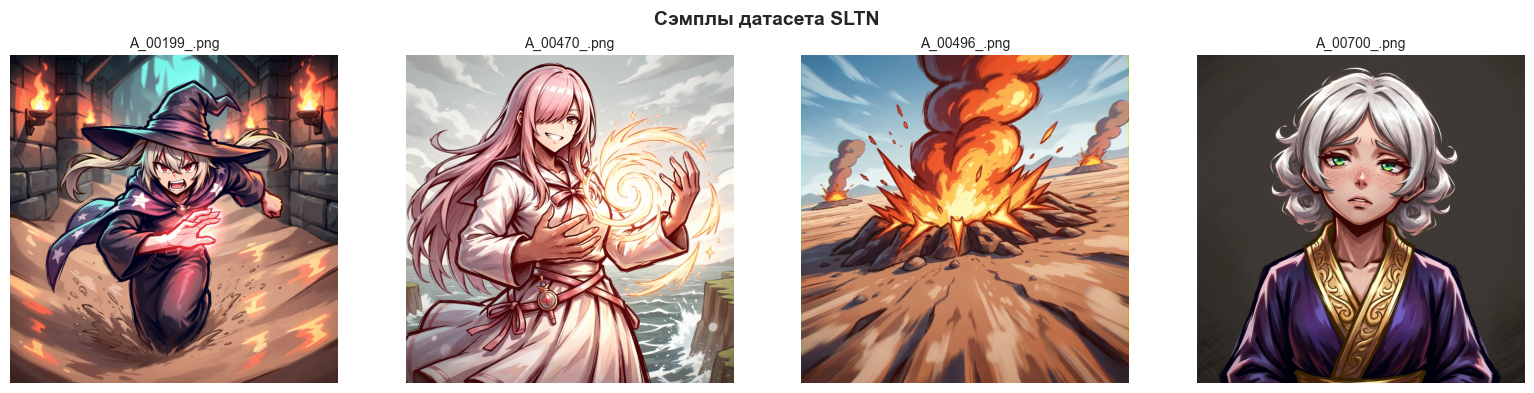

In [13]:
import matplotlib.image as mpimg
import random

image_files_sample = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if len(image_files_sample) >= 4:
    sample_images = random.sample(image_files_sample, 4)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img_name in zip(axes, sample_images):
        img_path = os.path.join(DATASET_DIR, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_name, fontsize=10)
    plt.suptitle('Сэмплы датасета SLTN', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Слишком мало изображений для отображения сэмплов.")

## 7. Интерактивная EDA-визуализация
Графики на основе РЕАЛЬНЫХ данных, которые мы только что извлекли из файлов аннотаций.

C:\Users\b8914\AppData\Local\Temp\ipykernel_33944\1649980454.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Subject', y='Count', data=df_subjects, palette='viridis', ax=ax)


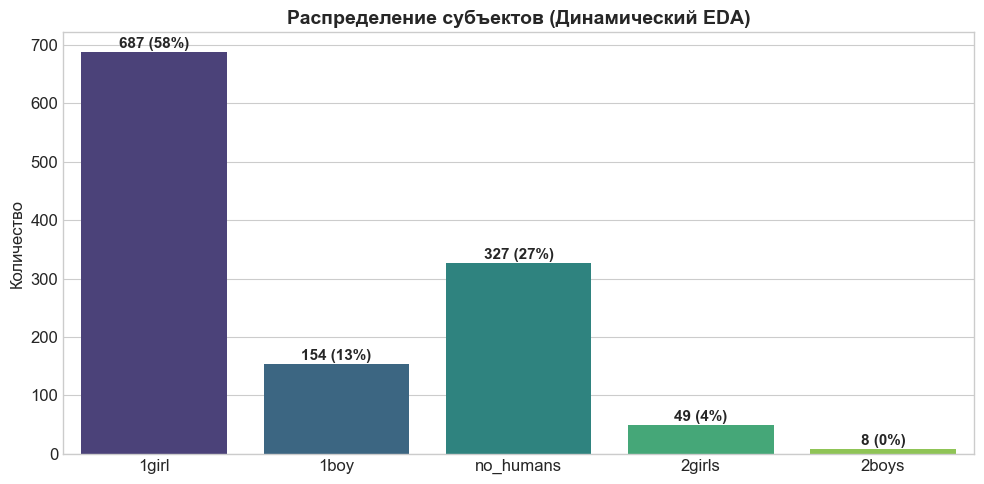

In [19]:
# Анализируем гендерный состав и субъекты на основе извлеченных тегов
subjects_data = {
    '1girl': tags_counter.get('1girl', 0),
    '1boy': tags_counter.get('1boy', 0),
    'no_humans': tags_counter.get('no humans', 0),
    '2girls': tags_counter.get('2girls', 0),
    '2boys': tags_counter.get('2boys', 0)
}

df_subjects = pd.DataFrame(list(subjects_data.items()), columns=['Subject', 'Count'])
df_subjects['Percentage'] = (df_subjects['Count'] / max(1, len(txt_files)) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='Subject', y='Count', data=df_subjects, palette='viridis', ax=ax)
plt.title('Распределение субъектов (Динамический EDA)', fontsize=14, fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({int(p.get_height()/max(1, len(txt_files))*100)}%)", 
                (p.get_x() + p.get_width() / 2., p.get_height() + (max(1, df_subjects['Count'].max()) * 0.02)), 
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\b8914\AppData\Local\Temp\ipykernel_33944\1143037068.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Composition', data=df_comp, palette='magma')


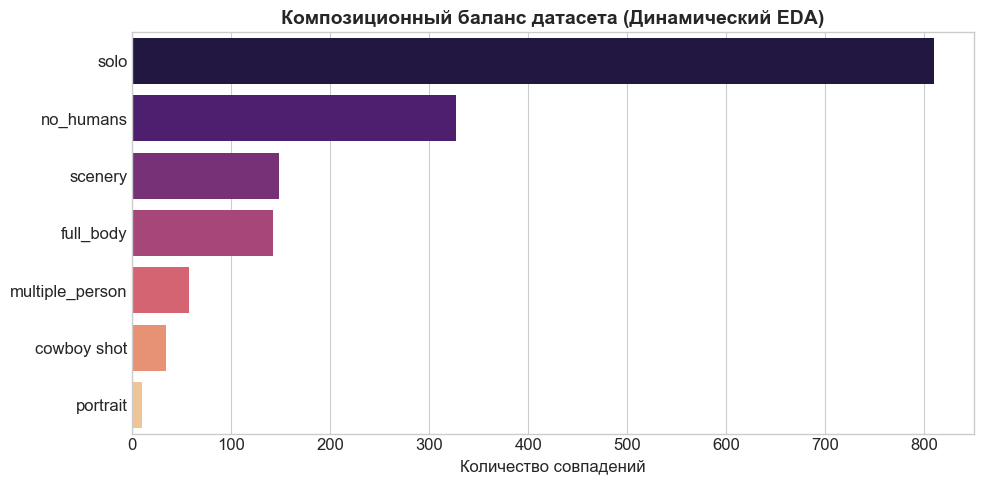

In [29]:
# Анализируем композиционный баланс на основе реальных тегов
composition_data = {
    'solo': tags_counter.get('solo', 0),
    'no_humans': tags_counter.get('no humans', 0),
    'full_body': tags_counter.get('full body', 0),
    'cowboy shot': tags_counter.get('cowboy shot', 0),
    'portrait': tags_counter.get('portrait', 0),
    'scenery': tags_counter.get('scenery', 0),
    'multiple_person': tags_counter.get('2boys', 0) + tags_counter.get('2girls', 0),
}

df_comp = pd.DataFrame(list(composition_data.items()), columns=['Composition', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Composition', data=df_comp, palette='magma')
plt.title('Композиционный баланс датасета (Динамический EDA)', fontsize=14, fontweight='bold')
plt.xlabel('Количество совпадений')
plt.ylabel('')
plt.tight_layout()
plt.show()

C:\Users\b8914\AppData\Local\Temp\ipykernel_33944\2969305377.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Environment', data=df_env, palette='coolwarm')


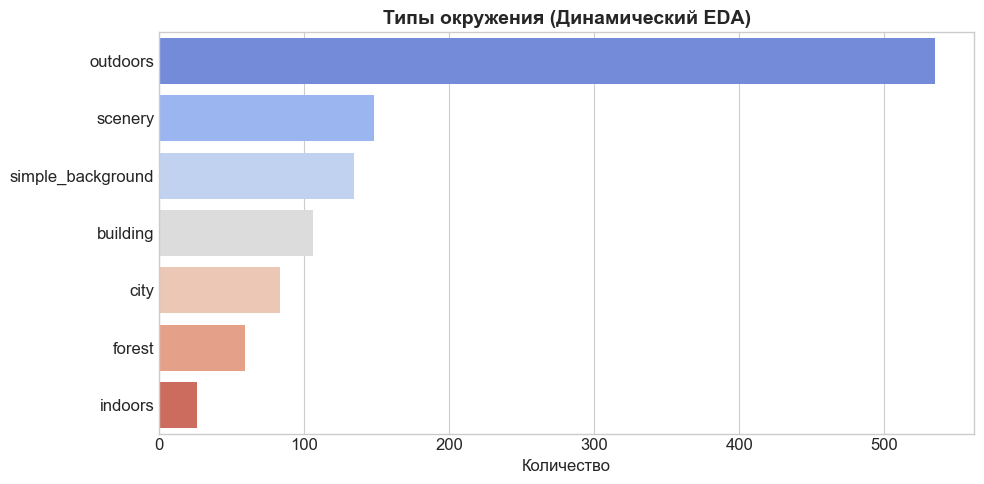

In [31]:
# Анализируем окружение на основе тегов локаций
env_data = {
    'outdoors': tags_counter.get('outdoors', 0),
    'indoors': tags_counter.get('indoors', 0),
    'scenery': tags_counter.get('scenery', 0),
    'building': tags_counter.get('building', 0),
    'city': tags_counter.get('city', 0),
    'forest': tags_counter.get('forest', 0),
    'simple_background': tags_counter.get('simple background', 0)
}

df_env = pd.DataFrame(list(env_data.items()), columns=['Environment', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Environment', data=df_env, palette='coolwarm')
plt.title('Типы окружения (Динамический EDA)', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

### Визуальные паттерны персонажей (Разнообразие черт внешности)

C:\Users\b8914\AppData\Local\Temp\ipykernel_33944\3007768556.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Pattern', data=df_vis, palette='Set2')


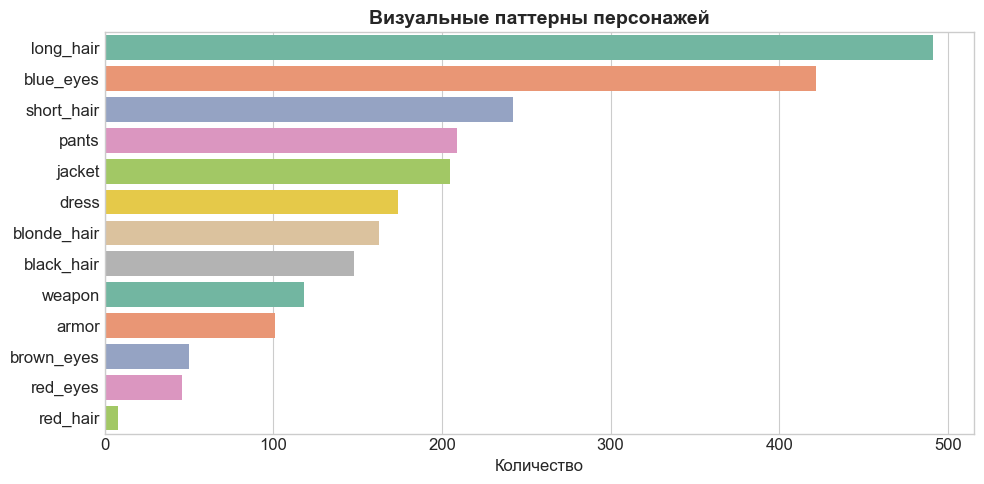

In [35]:
# Анализ визуальных паттернов персонажей (признаки)
visual_patterns_data = {
    'long_hair': tags_counter.get('long hair', 0),
    'short_hair': tags_counter.get('short hair', 0),
    'black_hair': tags_counter.get('black hair', 0),
    'blonde_hair': tags_counter.get('blonde hair', 0),
    'red_hair': tags_counter.get('red hair', 0),
    'brown_eyes': tags_counter.get('brown eyes', 0),
    'blue_eyes': tags_counter.get('blue eyes', 0),
    'red_eyes': tags_counter.get('red eyes', 0),
    'pants': tags_counter.get('pants', 0),
    'dress': tags_counter.get('dress', 0),
    'jacket': tags_counter.get('jacket', 0),
    'weapon': tags_counter.get('weapon', 0),
    'armor': tags_counter.get('armor', 0)
}

df_vis = pd.DataFrame(list(visual_patterns_data.items()), columns=['Pattern', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Pattern', data=df_vis, palette='Set2')
plt.title('Визуальные паттерны персонажей', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

## 7.5 Работа с редкими тегами (Удаление шума)
Для предотвращения размытия обучающего сигнала (и избегания проблем при тюнинге LoRA) отфильтруем теги, которые встречаются менее 5 раз.

In [36]:
MIN_FREQ = 5
rare_tags = {tag for tag, count in tags_counter.items() if count < MIN_FREQ and tag != TRIGGER_TOKEN}
print(f"Найдено {len(rare_tags)} редких тегов (частота < {MIN_FREQ}).")

if len(rare_tags) > 0:
    print("Удаляем редкие теги из .txt файлов...")
    for txt_name in tqdm(txt_files, desc="Удаление редких тегов"):
        txt_path = os.path.join(DATASET_DIR, txt_name)
        with open(txt_path, 'r', encoding='utf-8') as f:
            content = f.read().strip()
        
        tags = [t.strip() for t in content.split(',') if t.strip()]
        filtered_tags = [t for t in tags if t not in rare_tags]
        
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(", ".join(filtered_tags))
    print("✅ Редкие теги успешно удалены из аннотаций!")

Найдено 543 редких тегов (частота < 5).
Удаляем редкие теги из .txt файлов...


Удаление редких тегов: 100%|██████████| 1172/1172 [00:00<00:00, 4667.52it/s]

✅ Редкие теги успешно удалены из аннотаций!


## 8. Итоги и рекомендации

Мы успешно разметили исходные изображения через локальный WD-14 ONNX Tagger и извлекли реальное распределение тегов. На основе этих динамических метрик можно сделать точные выводы о качестве датасета для будущей тренировки.